<a href="https://colab.research.google.com/github/reenupalle/deepcodeguard/blob/main/notebooks/02_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Baseline Models

**DeepCodeGuard** · Week 2

Before building deep models we need **reference points**. Every later model (GRU, BiLSTM, Transformer, CodeBERT) must beat these, otherwise its extra complexity is not justified.

| Model | Input | Why it's here |
|---|---|---|
| Always secure / Always vulnerable | nothing | The floor: what you get without looking at the code |
| Length only | number of tokens | EDA showed vulnerable functions are slightly longer. How far does length alone get? |
| TF-IDF + Logistic Regression | bag of code tokens | Classical ML baseline from the spec |
| TF-IDF + MLP | bag of code tokens | First neural network: neurons, ReLU, dropout, backprop |

**Rules we follow for every model** (they'll be reused all project):
1. Train only on **train**.
2. Choose hyperparameters and the decision **threshold on validation**.
3. Evaluate on **test once**, at the very end.

> Runtime tip: **Runtime → Change runtime type → T4 GPU** makes the MLP faster, but CPU also works.

## 0 · Setup

In [2]:
!git clone -q https://github.com/reenupalle/deepcodeguard.git 2>/dev/null || (cd deepcodeguard && git pull -q)
%cd /content/deepcodeguard
!pip install -q datasets
!python src/deepcodeguard/data/download.py

/content/deepcodeguard
README.md: 100% 5.60k/5.60k [00:00<00:00, 14.4MB/s]

data/train-00000-of-00001.parquet: downloading bytes:  99% 17.7M/17.8M [00:01<00:00, 28.2MB/s, 1.05MB/s  ]
data/train-00000-of-00001.parquet: downloading bytes: 100% 17.7M/17.7M [00:01<00:00, 15.4MB/s, 1.70MB/s  ]
data/train-00000-of-00001.parquet: reconstructing file: 100% 17.8M/17.8M [00:01<00:00, 15.5MB/s, 1.73MB/s  ]

data/validation-00000-of-00001.parquet: downloading bytes:   2% 41.0k/2.21M [00:00<00:27, 79.1kB/s]
data/validation-00000-of-00001.parquet: downloading bytes: 100% 2.20M/2.20M [00:00<00:00, 3.63MB/s,  216kB/s  ]
data/validation-00000-of-00001.parquet: reconstructing file: 100% 2.21M/2.21M [00:00<00:00, 3.66MB/s,  218kB/s  ]

data/test-00000-of-00001.parquet: downloading bytes:   0% 0.00/2.23M [00:00<?, ?B/s]
data/test-00000-of-00001.parquet: downloading bytes: 100% 2.21M/2.21M [00:00<00:00, 5.33MB/s,  219kB/s  ]
data/test-00000-of-00001.parquet: reconstructing file: 100% 2.23M/2.23M [00:00<00:

## 1 · Load data and fix random seeds
Fixing seeds makes every run give the same numbers, so results in the report are reproducible.

In [3]:
import json
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

data = {s: pd.read_json(f"data/raw/{s}.jsonl", lines=True) for s in ["train", "validation", "test"]}
for s, d in data.items():
    d["target"] = d["target"].astype(int)
    print(f"{s:<11} {len(d):>6} rows, {100 * d['target'].mean():.1f}% vulnerable")

y_train, y_val, y_test = (data[s]["target"].values for s in ["train", "validation", "test"])
RESULTS = []

train        21854 rows, 45.8% vulnerable
validation    2732 rows, 43.4% vulnerable
test          2732 rows, 45.9% vulnerable


## 2 · Shared evaluation code
Every model outputs **P(vulnerable)**, a probability between 0 and 1. To turn it into a yes/no answer we need a threshold. The default is 0.5, but that is not always best, so we **search for the threshold that maximises F1 on validation**, then lock it before touching test.

Metrics:
- **Precision**: of the functions we flagged, how many were really vulnerable?
- **Recall**: of the truly vulnerable functions, how many did we catch?
- **F1**: harmonic mean of precision and recall, our **primary metric**
- **ROC-AUC / PR-AUC**: threshold-free ranking quality

In [4]:
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score,
                             precision_score, recall_score, roc_auc_score)


def best_threshold(y_true, probs):
    """Threshold in [0.05, 0.95] that maximises F1 on the given (validation) data."""
    grid = np.arange(0.05, 0.96, 0.01)
    scores = [f1_score(y_true, probs >= t, zero_division=0) for t in grid]
    return float(grid[int(np.argmax(scores))])


def evaluate(y_true, probs, threshold):
    pred = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs) if len(set(probs)) > 1 else 0.5,
        "pr_auc": average_precision_score(y_true, probs),
    }


def report(name, val_probs, test_probs, **extra):
    t = best_threshold(y_val, val_probs)
    val = evaluate(y_val, val_probs, t)
    test = evaluate(y_test, test_probs, t)
    RESULTS.append({"model": name, "threshold": round(t, 2),
                    "val_f1": val["f1"], **{f"test_{k}": v for k, v in test.items()}, **extra})
    print(f"{name}: threshold={t:.2f}  val F1={val['f1']:.3f}  |  "
          + "  ".join(f"test {k}={v:.3f}" for k, v in test.items()))

## 3 · Baseline A: trivial predictors
Two "models" that don't look at the code at all:
- **Always secure** (majority class): its accuracy is the share of secure functions (~54%), but F1 is 0 because it never finds a vulnerability.
- **Always vulnerable**: recall is 100%, and F1 is around **0.63** just by flagging everything!

**This is important:** with ~46% vulnerable functions, an F1 of about 0.63 is free. A real model has to beat that on F1 *and* show a ROC-AUC clearly above 0.5, which tells us it actually ranks vulnerable code higher.

In [5]:
from sklearn.dummy import DummyClassifier

for name, strategy in [("Always secure", "most_frequent"), ("Always vulnerable", "constant")]:
    dummy = DummyClassifier(strategy=strategy, constant=1).fit(np.zeros((len(y_train), 1)), y_train)
    pred = dummy.predict(np.zeros((len(y_test), 1)))
    row = evaluate(y_test, pred.astype(float), threshold=0.5)
    RESULTS.append({"model": name, **{f"test_{k}": v for k, v in row.items()}})
    print(f"{name:<18} test accuracy={row['accuracy']:.3f}  test F1={row['f1']:.3f}")

Always secure      test accuracy=0.541  test F1=0.000
Always vulnerable  test accuracy=0.459  test F1=0.630


## 4 · Baseline B: length only
A logistic regression that sees **only log(number of tokens)**. If a deep model barely beats this, it is mostly learning "long functions are risky", not real vulnerability patterns. Look at its **ROC-AUC**: close to 0.5 means length is nearly useless.

In [6]:
from sklearn.linear_model import LogisticRegression

TOKEN_RE = re.compile(r"[A-Za-z_]\w*|\d+|\S")   # identifiers, numbers, single symbols


def log_length(df):
    return np.log1p(df["func"].map(lambda c: len(TOKEN_RE.findall(c)))).values.reshape(-1, 1)


length_lr = LogisticRegression().fit(log_length(data["train"]), y_train)
report("Length only",
       length_lr.predict_proba(log_length(data["validation"]))[:, 1],
       length_lr.predict_proba(log_length(data["test"]))[:, 1])

Length only: threshold=0.05  val F1=0.606  |  test accuracy=0.459  test precision=0.459  test recall=1.000  test f1=0.630  test roc_auc=0.514  test pr_auc=0.464


## 5 · Turn code into TF-IDF features
We split code into tokens (`memcpy`, `(`, `buf`, `->` ...) and use **unigrams and bigrams** (single tokens and pairs like `free (`).

**TF-IDF** gives each token a weight: high if it is frequent in *this* function but rare across *all* functions. Each function becomes a sparse vector of 50,000 numbers. Word order beyond pairs is lost, which is exactly the limitation the RNNs will address next week.

The vocabulary is learned on **train only**.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    tokenizer=TOKEN_RE.findall, lowercase=False, token_pattern=None,
    ngram_range=(1, 2), max_features=50_000, min_df=2, sublinear_tf=True,
)
X_train = vectorizer.fit_transform(data["train"]["func"])
X_val = vectorizer.transform(data["validation"]["func"])
X_test = vectorizer.transform(data["test"]["func"])
print("TF-IDF matrix:", X_train.shape, "| example features:", vectorizer.get_feature_names_out()[:: X_train.shape[1] // 8][:8])

TF-IDF matrix: (21854, 50000) | example features: ['!' ', mxf' '= pred' "P '" 'chosen "' 'h264chroma' 'operation *'
 'start_dts']


## 6 · Baseline C: TF-IDF + Logistic Regression
`C` controls regularisation (smaller = simpler model). We try a few values and **pick the best by validation F1**, never by test.

In [8]:
best = None
for C in [0.1, 0.3, 1.0, 3.0, 10.0]:
    clf = LogisticRegression(C=C, max_iter=2000).fit(X_train, y_train)
    p_val = clf.predict_proba(X_val)[:, 1]
    f1 = f1_score(y_val, p_val >= best_threshold(y_val, p_val))
    print(f"C={C:<5} val F1={f1:.3f}")
    if best is None or f1 > best[0]:
        best = (f1, C, clf)

_, best_C, lr = best
print(f"\nChosen C={best_C}")
report("TF-IDF + LogReg", lr.predict_proba(X_val)[:, 1], lr.predict_proba(X_test)[:, 1], C=best_C)

C=0.1   val F1=0.635
C=0.3   val F1=0.641
C=1.0   val F1=0.647
C=3.0   val F1=0.646
C=10.0  val F1=0.645

Chosen C=1.0
TF-IDF + LogReg: threshold=0.34  val F1=0.647  |  test accuracy=0.582  test precision=0.527  test recall=0.891  test f1=0.662  test roc_auc=0.684  test pr_auc=0.639


**What did it learn?** The tokens with the largest positive weights push towards "vulnerable", the most negative towards "secure". Useful for the report, but remember these are correlations in this dataset, not proof of causes.

In [9]:
names = vectorizer.get_feature_names_out()
order = np.argsort(lr.coef_[0])
print("Most 'vulnerable' features:", list(names[order[-15:]][::-1]))
print("Most 'secure' features:    ", list(names[order[:15]]))

Most 'vulnerable' features: ['gen_inval_exception', 'gen_inval_exception (', ', hwaddr', '( buffer', '< s', ', uint8_t', '; if', 'dev', 'qsb', 'qdev_init', 'qdev_init (', '= rpath', '; qdev_init', 'temp', 'f .']
Most 'secure' features:     ['}', '; }', 'target_phys_addr_t', ', target_phys_addr_t', '} }', 'target_phys_addr_t addr', '} if', ') return', 'float32', ', __FUNCTION__', '__FUNCTION__', 'coded_frame )', ', dst', 'coded_frame', 'fail_unless (']


## 7 · Baseline D: TF-IDF + MLP (first neural network)
Architecture from the spec:

`TF-IDF (50k) → Dense 512 → ReLU → Dropout → Dense 128 → ReLU → Dropout → Dense 1 → Sigmoid`

- **Dense layers** are neurons computing weighted sums.
- **ReLU** is the non-linearity, which lets the network learn more than a straight line.
- **Dropout** randomly switches off neurons during training to reduce overfitting.
- **Loss**: binary cross-entropy. **Optimiser**: Adam. Gradients come from **backpropagation**.
- **Early stopping**: after each epoch we check validation ROC-AUC and keep the best weights. If it hasn't improved for 3 epochs, we stop.

In [10]:
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Training on:", device)


class MLP(nn.Module):
    def __init__(self, n_features, dropout=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 512), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1),   # sigmoid is applied inside the loss for numerical stability
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def to_tensor(sparse_rows):
    return torch.tensor(sparse_rows.toarray(), dtype=torch.float32, device=device)


def predict(model, X, batch_size=1024):
    model.eval()
    with torch.no_grad():
        return np.concatenate([torch.sigmoid(model(to_tensor(X[i:i + batch_size]))).cpu().numpy()
                               for i in range(0, X.shape[0], batch_size)])


mlp = MLP(X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.BCEWithLogitsLoss()
y_train_t = torch.tensor(y_train, dtype=torch.float32, device=device)

BATCH, MAX_EPOCHS, PATIENCE = 64, 20, 3
best_auc, best_state, bad_epochs, history = 0.0, None, 0, []
start = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    mlp.train()
    perm = np.random.permutation(X_train.shape[0])
    total = 0.0
    for i in range(0, len(perm), BATCH):
        idx = perm[i:i + BATCH]
        optimizer.zero_grad()
        loss = loss_fn(mlp(to_tensor(X_train[idx])), y_train_t[idx])
        loss.backward()        # backpropagation
        optimizer.step()       # gradient descent step
        total += loss.item() * len(idx)
    val_auc = roc_auc_score(y_val, predict(mlp, X_val))
    history.append({"epoch": epoch, "train_loss": total / len(perm), "val_roc_auc": val_auc})
    print(f"epoch {epoch:>2}  train loss {total / len(perm):.4f}  val ROC-AUC {val_auc:.4f}")
    if val_auc > best_auc:
        best_auc, bad_epochs = val_auc, 0
        best_state = {k: v.detach().clone() for k, v in mlp.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print("Early stopping.")
            break

mlp.load_state_dict(best_state)
n_params = sum(p.numel() for p in mlp.parameters())
report("TF-IDF + MLP", predict(mlp, X_val), predict(mlp, X_test),
       params=n_params, train_seconds=round(time.time() - start))

Training on: cuda
epoch  1  train loss 0.6535  val ROC-AUC 0.6915
epoch  2  train loss 0.5551  val ROC-AUC 0.6922
epoch  3  train loss 0.4743  val ROC-AUC 0.6961
epoch  4  train loss 0.4068  val ROC-AUC 0.6866
epoch  5  train loss 0.3495  val ROC-AUC 0.6800
epoch  6  train loss 0.3106  val ROC-AUC 0.6723
Early stopping.
TF-IDF + MLP: threshold=0.17  val F1=0.648  |  test accuracy=0.578  test precision=0.524  test recall=0.908  test f1=0.664  test roc_auc=0.675  test pr_auc=0.639


**Learning curve.** Training loss should go down. If validation ROC-AUC peaks early and then falls, that's overfitting, and why we use early stopping and dropout.

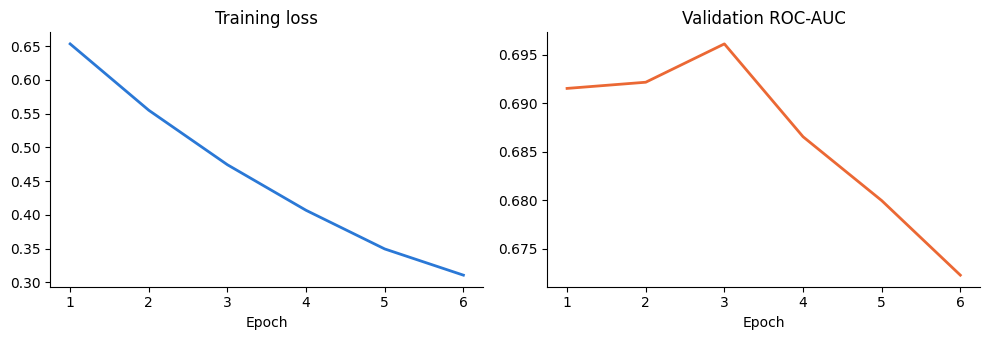

In [11]:
import matplotlib.pyplot as plt

h = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(h["epoch"], h["train_loss"], color="#2a78d6", linewidth=2)
axes[0].set_title("Training loss")
axes[1].plot(h["epoch"], h["val_roc_auc"], color="#eb6834", linewidth=2)
axes[1].set_title("Validation ROC-AUC")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("reports/figures/mlp_learning_curve.png", dpi=150)
plt.show()

## 8 · Results table
This table goes straight into the report and is the bar the deep models must clear.

In [12]:
cols = ["model", "threshold", "test_accuracy", "test_precision", "test_recall",
        "test_f1", "test_roc_auc", "test_pr_auc"]
table = pd.DataFrame(RESULTS)[cols].round(3)
Path("reports/tables").mkdir(parents=True, exist_ok=True)
table.to_csv("reports/tables/baselines.csv", index=False)
Path("experiments/baselines").mkdir(parents=True, exist_ok=True)
json.dump({"seed": SEED, "results": RESULTS}, open("experiments/baselines/metrics.json", "w"),
          indent=2, default=float)
table

,model,threshold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,Always secure,NaN,0.541,0.000,0.000,0.000,0.500,0.459
1,Always vulnerable,NaN,0.459,0.459,1.000,0.630,0.500,0.459
2,Length only,0.05,0.459,0.459,1.000,0.630,0.514,0.464
3,TF-IDF + LogReg,0.34,0.582,0.527,0.891,0.662,0.684,0.639
4,TF-IDF + MLP,0.17,0.578,0.524,0.908,0.664,0.675,0.639


## Findings
_Fill in after running: which baseline is best, how far it is above the majority class and the length-only model, and what the top TF-IDF features suggest._